# DBSCAN Klaszterezés - Bank Marketing Dataset
## Density-Based Spatial Clustering (Age és Balance)

### Célkitűzések:
- DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
- 2 változó: **age** (életkor) és **balance** (egyenleg)
- Epsilon (ε) optimalizálása k-distance graph módszerrel
- MinPts = 4 (2 × dimenziószám)
- Noise pontok (outliers) azonosítása és monitorozása
- Validációs metrikák és klaszter profilozás
- **Exportálás: exports_dbscan mappába**

## 1. Könyvtárak importálása

In [3]:
# Alapvető könyvtárak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

# Sklearn könyvtárak
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Matplotlib beállítások
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# Export mappa létrehozása
os.makedirs('exports_dbscan', exist_ok=True)

print("✓ Könyvtárak sikeresen betöltve!")
print("✓ exports_dbscan mappa ellenőrizve/létrehozva!")

✓ Könyvtárak sikeresen betöltve!
✓ exports_dbscan mappa ellenőrizve/létrehozva!


## 2. Adatok betöltése és előkészítése

In [4]:
# Adathalmaz beolvasása
root = r"bank+marketing\bank\bank-full.csv"
df = pd.read_csv(root, sep=';')

print("="*70)
print("ADATOK BETÖLTÉSE")
print("="*70)
print(f"Sorok száma: {len(df):,}")
print(f"Oszlopok száma: {len(df.columns)}")
print("\nElső 5 sor (age, balance):")
print(df[['age', 'balance']].head())
print("\nStatisztikák:")
print(df[['age', 'balance']].describe())

ADATOK BETÖLTÉSE
Sorok száma: 45,211
Oszlopok száma: 17

Első 5 sor (age, balance):
   age  balance
0   58     2143
1   44       29
2   33        2
3   47     1506
4   33        1

Statisztikák:
                age        balance
count  45211.000000   45211.000000
mean      40.936210    1362.272058
std       10.618762    3044.765829
min       18.000000   -8019.000000
25%       33.000000      72.000000
50%       39.000000     448.000000
75%       48.000000    1428.000000
max       95.000000  102127.000000


In [5]:
# Feature Selection: age és balance
features = ['age', 'balance']
X = df[features].copy()

print("\n" + "="*70)
print("FEATURE SELECTION ÉS NORMALIZÁLÁS")
print("="*70)
print(f"Kiválasztott változók: {features}")
print(f"Adatpontok száma: {len(X):,}")
print(f"Dimenziószám: {X.shape[1]}")

# Normalizálás: StandardScaler (KRITIKUS DBSCAN-hez!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n✓ Adatok normalizálva (StandardScaler)!")
print(f"  X_scaled alakja: {X_scaled.shape}")
print(f"  Átlag: {X_scaled.mean(axis=0)}")
print(f"  Szórás: {X_scaled.std(axis=0)}")


FEATURE SELECTION ÉS NORMALIZÁLÁS
Kiválasztott változók: ['age', 'balance']
Adatpontok száma: 45,211
Dimenziószám: 2

✓ Adatok normalizálva (StandardScaler)!
  X_scaled alakja: (45211, 2)
  Átlag: [2.1122502e-16 1.7602085e-17]
  Szórás: [1. 1.]


## 3. MinPts Paraméter Meghatározása

In [6]:
# MinPts meghatározása: általában 2 × dimenziószám
n_dimensions = X_scaled.shape[1]
min_pts = 2 * n_dimensions

print("="*70)
print("MinPts PARAMÉTER MEGHATÁROZÁSA")
print("="*70)
print(f"Dimenziószám: {n_dimensions}")
print(f"MinPts = 2 × {n_dimensions} = {min_pts}")
print("\nMinPts jelentése:")
print(f"  Egy pont legalább {min_pts} szomszédot kell, hogy tartalmazzon")
print(f"  az epsilon (ε) távolságon belül, hogy core pont legyen.")
print("="*70)

MinPts PARAMÉTER MEGHATÁROZÁSA
Dimenziószám: 2
MinPts = 2 × 2 = 4

MinPts jelentése:
  Egy pont legalább 4 szomszédot kell, hogy tartalmazzon
  az epsilon (ε) távolságon belül, hogy core pont legyen.


## 4. Epsilon (ε) Optimalizálása - k-distance Graph

In [7]:
# k-distance számítása (k = MinPts)
print("="*70)
print("K-DISTANCE GRAPH SZÁMÍTÁSA")
print("="*70)
print(f"k = MinPts = {min_pts}")
print("Nearest Neighbors számítása...")

# NearestNeighbors minden pontra
neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# k-edik legközelebbi szomszéd távolsága (utolsó oszlop)
k_distances = distances[:, -1]
k_distances_sorted = np.sort(k_distances)

print(f"✓ k-distance értékek kiszámítva ({len(k_distances):,} pont)")
print(f"\nk-distance statisztikák:")
print(f"  Min:    {k_distances.min():.4f}")
print(f"  Max:    {k_distances.max():.4f}")
print(f"  Átlag:  {k_distances.mean():.4f}")
print(f"  Medián: {np.median(k_distances):.4f}")
print(f"  95%:    {np.percentile(k_distances, 95):.4f}")

K-DISTANCE GRAPH SZÁMÍTÁSA
k = MinPts = 4
Nearest Neighbors számítása...
✓ k-distance értékek kiszámítva (45,211 pont)

k-distance statisztikák:
  Min:    0.0000
  Max:    7.5419
  Átlag:  0.0103
  Medián: 0.0010
  95%:    0.0424


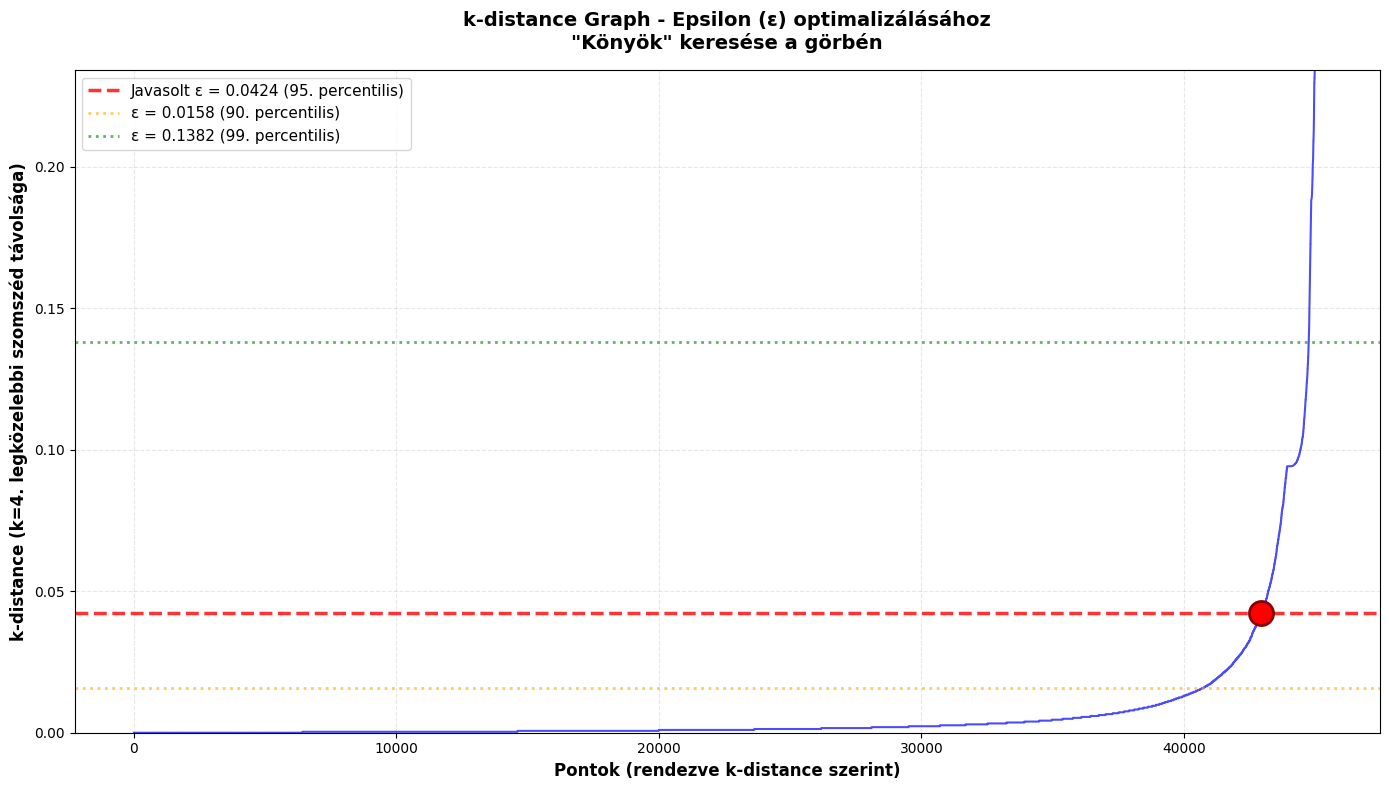


✓ k-distance graph mentve: exports_dbscan/kdistance_graph.png

JAVASOLT EPSILON ÉRTÉKEK
  90. percentilis: ε = 0.0158
  95. percentilis: ε = 0.0424 ⭐ AJÁNLOTT
  99. percentilis: ε = 0.1382


In [8]:
# k-distance graph vizualizációja
fig, ax = plt.subplots(figsize=(14, 8))

# k-distance plot
ax.plot(range(len(k_distances_sorted)), k_distances_sorted, 'b-', linewidth=1.5, alpha=0.7)

# "Könyök" keresése - ahol a legnagyobb a változás
# Egyszerű heurisztika: 95. percentilis körül
suggested_eps = np.percentile(k_distances, 95)
suggested_idx = np.searchsorted(k_distances_sorted, suggested_eps)

ax.axhline(y=suggested_eps, color='red', linestyle='--', linewidth=2.5, 
          label=f'Javasolt ε = {suggested_eps:.4f} (95. percentilis)', alpha=0.8)
ax.scatter([suggested_idx], [suggested_eps], color='red', s=300, zorder=5, 
          marker='o', edgecolors='darkred', linewidths=2)

# Alternatív epsilon értékek jelölése
eps_90 = np.percentile(k_distances, 90)
eps_99 = np.percentile(k_distances, 99)
ax.axhline(y=eps_90, color='orange', linestyle=':', linewidth=2, 
          label=f'ε = {eps_90:.4f} (90. percentilis)', alpha=0.6)
ax.axhline(y=eps_99, color='green', linestyle=':', linewidth=2, 
          label=f'ε = {eps_99:.4f} (99. percentilis)', alpha=0.6)

ax.set_xlabel('Pontok (rendezve k-distance szerint)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'k-distance (k={min_pts}. legközelebbi szomszéd távolsága)', 
             fontsize=12, fontweight='bold')
ax.set_title('k-distance Graph - Epsilon (ε) optimalizálásához\n' + 
            '"Könyök" keresése a görbén', 
            fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')

# Y tengely határok beállítása a jobb láthatóságért
ax.set_ylim([0, np.percentile(k_distances, 99.5)])

plt.tight_layout()
plt.savefig('exports_dbscan/kdistance_graph.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ k-distance graph mentve: exports_dbscan/kdistance_graph.png")
print("\n" + "="*70)
print("JAVASOLT EPSILON ÉRTÉKEK")
print("="*70)
print(f"  90. percentilis: ε = {eps_90:.4f}")
print(f"  95. percentilis: ε = {suggested_eps:.4f} ⭐ AJÁNLOTT")
print(f"  99. percentilis: ε = {eps_99:.4f}")
print("="*70)

## 5. DBSCAN Klaszterezés - Többféle Epsilon Tesztelése

In [9]:
# Többféle epsilon értékkel tesztelünk
epsilon_values = [
    eps_90,
    suggested_eps,  # eps_95
    eps_99,
    (eps_90 + suggested_eps) / 2,  # Köztes érték
]

epsilon_values = sorted(epsilon_values)

print("="*90)
print("DBSCAN FUTTATÁSA KÜLÖNBÖZŐ EPSILON ÉRTÉKEKKEL")
print(f"MinPts = {min_pts}")
print("="*90)

results = []

for eps in epsilon_values:
    # DBSCAN futtatása
    dbscan = DBSCAN(eps=eps, min_samples=min_pts)
    labels = dbscan.fit_predict(X_scaled)
    
    # Statisztikák
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels) * 100
    
    # Core pontok száma
    n_core = len(dbscan.core_sample_indices_)
    
    # Validációs metrikák (csak ha van legalább 2 klaszter és nem túl sok noise)
    if n_clusters >= 2 and noise_ratio < 100:
        # Metrikák számítása noise nélkül
        mask = labels != -1
        if mask.sum() > 0:
            try:
                silhouette = silhouette_score(X_scaled[mask], labels[mask])
                davies_bouldin = davies_bouldin_score(X_scaled[mask], labels[mask])
                calinski = calinski_harabasz_score(X_scaled[mask], labels[mask])
            except:
                silhouette = davies_bouldin = calinski = np.nan
        else:
            silhouette = davies_bouldin = calinski = np.nan
    else:
        silhouette = davies_bouldin = calinski = np.nan
    
    results.append({
        'epsilon': eps,
        'n_clusters': n_clusters,
        'n_core': n_core,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski,
        'labels': labels,
        'dbscan': dbscan
    })
    
    status = "✓" if noise_ratio <= 15 else "⚠"
    
    print(f"\nε = {eps:.4f}:")
    print(f"  Klaszterek száma:     {n_clusters}")
    print(f"  Core pontok:          {n_core:,} ({n_core/len(labels)*100:.1f}%)")
    print(f"  Noise pontok:         {n_noise:,} ({noise_ratio:.2f}%) {status}")
    if not np.isnan(silhouette):
        print(f"  Silhouette Score:     {silhouette:.4f}")
        print(f"  Davies-Bouldin:       {davies_bouldin:.4f}")
        print(f"  Calinski-Harabasz:    {calinski:.2f}")

print("\n" + "="*90)

DBSCAN FUTTATÁSA KÜLÖNBÖZŐ EPSILON ÉRTÉKEKKEL
MinPts = 4

ε = 0.0158:
  Klaszterek száma:     596
  Core pontok:          40,701 (90.0%)
  Noise pontok:         3,835 (8.48%) ✓
  Silhouette Score:     0.0791
  Davies-Bouldin:       0.5386
  Calinski-Harabasz:    1944.99

ε = 0.0291:
  Klaszterek száma:     431
  Core pontok:          42,253 (93.5%)
  Noise pontok:         2,493 (5.51%) ✓
  Silhouette Score:     0.0341
  Davies-Bouldin:       0.8035
  Calinski-Harabasz:    1497.55

ε = 0.0424:
  Klaszterek száma:     337
  Core pontok:          42,955 (95.0%)
  Noise pontok:         1,915 (4.24%) ✓
  Silhouette Score:     0.0016
  Davies-Bouldin:       1.0802
  Calinski-Harabasz:    1247.83

ε = 0.1382:
  Klaszterek száma:     36
  Core pontok:          44,758 (99.0%)
  Noise pontok:         366 (0.81%) ✓
  Silhouette Score:     0.4334
  Davies-Bouldin:       0.4758
  Calinski-Harabasz:    121.70



## 6. Optimális Epsilon Kiválasztása

In [10]:
# Optimális epsilon kiválasztása: noise < 15% ÉS legjobb Silhouette Score
valid_results = [r for r in results if r['noise_ratio'] <= 15 and not np.isnan(r['silhouette'])]

if len(valid_results) > 0:
    # Legjobb Silhouette Score-t választjuk
    optimal_result = max(valid_results, key=lambda x: x['silhouette'])
    print("="*90)
    print("OPTIMÁLIS EPSILON KIVÁLASZTVA")
    print("="*90)
    print(f"Kritériumok: noise ≤ 15% ÉS legjobb Silhouette Score")
    print(f"\nOptimális ε = {optimal_result['epsilon']:.4f}")
    print(f"  Klaszterek száma:     {optimal_result['n_clusters']}")
    print(f"  Noise arány:          {optimal_result['noise_ratio']:.2f}% ✓")
    print(f"  Silhouette Score:     {optimal_result['silhouette']:.4f}")
    print(f"  Davies-Bouldin:       {optimal_result['davies_bouldin']:.4f}")
    print(f"  Calinski-Harabasz:    {optimal_result['calinski_harabasz']:.2f}")
    print("="*90)
else:
    # Ha nincs megfelelő, válasszuk a legkevesebb noise-zal rendelkezőt
    optimal_result = min(results, key=lambda x: x['noise_ratio'])
    print("="*90)
    print("⚠ FIGYELMEZTETÉS: Nincs olyan epsilon, ahol noise ≤ 15%")
    print("="*90)
    print(f"Legkisebb noise arányú epsilon választva: ε = {optimal_result['epsilon']:.4f}")
    print(f"  Klaszterek száma:     {optimal_result['n_clusters']}")
    print(f"  Noise arány:          {optimal_result['noise_ratio']:.2f}% ⚠")
    print(f"\n⚠ DBSCAN nem megfelelő erre az adathalmazra!")
    print(f"  - Túl sok noise pont (>{optimal_result['noise_ratio']:.1f}%)")
    print(f"  - Az adathalmaz valószínűleg nem tartalmaz jól elkülöníthető")
    print(f"    sűrűség-alapú klasztereket.")
    print("="*90)

# Optimális modell és címkék
optimal_labels = optimal_result['labels']
optimal_dbscan = optimal_result['dbscan']
optimal_eps = optimal_result['epsilon']

# Címkék hozzáadása az adathalmazhoz
df['cluster'] = optimal_labels

OPTIMÁLIS EPSILON KIVÁLASZTVA
Kritériumok: noise ≤ 15% ÉS legjobb Silhouette Score

Optimális ε = 0.1382
  Klaszterek száma:     36
  Noise arány:          0.81% ✓
  Silhouette Score:     0.4334
  Davies-Bouldin:       0.4758
  Calinski-Harabasz:    121.70


## 7. Eredmények Összefoglaló Táblázata

In [11]:
# Eredmények DataFrame
results_df = pd.DataFrame([{
    'Epsilon': r['epsilon'],
    'Klaszterek': r['n_clusters'],
    'Core pontok': r['n_core'],
    'Noise pontok': r['n_noise'],
    'Noise %': r['noise_ratio'],
    'Silhouette': r['silhouette'],
    'Davies-Bouldin': r['davies_bouldin'],
    'Calinski-Harabasz': r['calinski_harabasz']
} for r in results])

# Megfelelőség jelölése
results_df['Megfelelő'] = results_df['Noise %'].apply(lambda x: '✓' if x <= 15 else '✗')

print("\n" + "="*100)
print("DBSCAN EREDMÉNYEK ÖSSZEFOGLALÁSA")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Exportálás
results_df.to_csv('exports_dbscan/dbscan_parameters.csv', index=False, encoding='utf-8-sig')
print("\n✓ Paraméter összefoglaló exportálva: exports_dbscan/dbscan_parameters.csv")


DBSCAN EREDMÉNYEK ÖSSZEFOGLALÁSA
 Epsilon  Klaszterek  Core pontok  Noise pontok  Noise %  Silhouette  Davies-Bouldin  Calinski-Harabasz Megfelelő
0.015765         596        40701          3835 8.482449    0.079055        0.538608        1944.993489         ✓
0.029067         431        42253          2493 5.514145    0.034098        0.803542        1497.549168         ✓
0.042368         337        42955          1915 4.235695    0.001619        1.080224        1247.826124         ✓
0.138185          36        44758           366 0.809538    0.433398        0.475814         121.697288         ✓

✓ Paraméter összefoglaló exportálva: exports_dbscan/dbscan_parameters.csv


## 8. Validációs Metrikák (Optimális Modell)

In [12]:
# Validációs metrikák az optimális modellre
metrics_df = pd.DataFrame({
    'Metrika': [
        'Optimális Epsilon (ε)',
        'MinPts',
        'Klaszterek száma',
        'Core pontok',
        'Noise pontok',
        'Noise arány (%)',
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Calinski-Harabasz Index'
    ],
    'Érték': [
        f"{optimal_eps:.4f}",
        min_pts,
        optimal_result['n_clusters'],
        optimal_result['n_core'],
        optimal_result['n_noise'],
        f"{optimal_result['noise_ratio']:.2f}",
        f"{optimal_result['silhouette']:.4f}" if not np.isnan(optimal_result['silhouette']) else 'N/A',
        f"{optimal_result['davies_bouldin']:.4f}" if not np.isnan(optimal_result['davies_bouldin']) else 'N/A',
        f"{optimal_result['calinski_harabasz']:.2f}" if not np.isnan(optimal_result['calinski_harabasz']) else 'N/A'
    ],
    'Megjegyzés': [
        '95. percentilis (k-distance)',
        '2 × dimenziószám',
        'Noise nélkül',
        f"{optimal_result['n_core']/len(df)*100:.1f}%",
        '✓ Megfelelő' if optimal_result['noise_ratio'] <= 15 else '⚠ Túl magas',
        'Cél: ≤15%',
        'Magasabb = jobb (noise nélkül)',
        'Alacsonyabb = jobb',
        'Magasabb = jobb'
    ]
})

print("\n" + "="*100)
print("VALIDÁCIÓS METRIKÁK - OPTIMÁLIS DBSCAN MODELL")
print("="*100)
print(metrics_df.to_string(index=False))
print("="*100)

# Exportálás
metrics_df.to_csv('exports_dbscan/dbscan_metrics.csv', index=False, encoding='utf-8-sig')
print("\n✓ Metrikák exportálva: exports_dbscan/dbscan_metrics.csv")


VALIDÁCIÓS METRIKÁK - OPTIMÁLIS DBSCAN MODELL
                Metrika  Érték                     Megjegyzés
  Optimális Epsilon (ε) 0.1382   95. percentilis (k-distance)
                 MinPts      4               2 × dimenziószám
       Klaszterek száma     36                   Noise nélkül
            Core pontok  44758                          99.0%
           Noise pontok    366                    ✓ Megfelelő
        Noise arány (%)   0.81                      Cél: ≤15%
       Silhouette Score 0.4334 Magasabb = jobb (noise nélkül)
   Davies-Bouldin Index 0.4758             Alacsonyabb = jobb
Calinski-Harabasz Index 121.70                Magasabb = jobb

✓ Metrikák exportálva: exports_dbscan/dbscan_metrics.csv


## 9. Klaszter Profilozás

In [13]:
# Klaszter profilozás (külön a noise pontokkal)
cluster_profile = []

unique_labels = sorted(set(optimal_labels))

for cluster_id in unique_labels:
    cluster_data = df[df['cluster'] == cluster_id]
    
    profile = {
        'Klaszter': 'Noise' if cluster_id == -1 else f'Cluster_{cluster_id}',
        'Klaszter_ID': cluster_id,
        'Átlag age': cluster_data['age'].mean(),
        'Szórás age': cluster_data['age'].std(),
        'Átlag balance': cluster_data['balance'].mean(),
        'Szórás balance': cluster_data['balance'].std(),
        'Elemszám (db)': len(cluster_data),
        'Elemszám (%)': len(cluster_data) / len(df) * 100
    }
    cluster_profile.append(profile)

profile_df = pd.DataFrame(cluster_profile)

print("\n" + "="*100)
print("KLASZTER PROFILOZÁS - DBSCAN")
print("="*100)
print(profile_df.to_string(index=False))
print("="*100)

# Exportálás
profile_df.to_csv('exports_dbscan/dbscan_cluster_profiles.csv', index=False, encoding='utf-8-sig')
print("\n✓ Klaszter profilok exportálva: exports_dbscan/dbscan_cluster_profiles.csv")


KLASZTER PROFILOZÁS - DBSCAN
  Klaszter  Klaszter_ID  Átlag age  Szórás age  Átlag balance  Szórás balance  Elemszám (db)  Elemszám (%)
     Noise           -1  50.330601   17.167586   20429.183060    14750.964309            366      0.809538
 Cluster_0            0  40.782035   10.409532    1142.278952     1909.327026          44599     98.646347
 Cluster_1            1  59.461538    1.126601   13285.384615      303.928867             13      0.028754
 Cluster_2            2  42.555556    1.424001   15527.777778      154.196934              9      0.019907
 Cluster_3            3  58.357143    1.277446   11955.142857      354.925313             14      0.030966
 Cluster_4            4  31.857143    0.949262   14855.071429      397.512934             14      0.030966
 Cluster_5            5  33.300000    0.823273   17815.600000      325.272262             10      0.022119
 Cluster_6            6  37.142857    1.214986   16688.571429      262.553396              7      0.015483
 Cluste

## 10. Vizualizációk

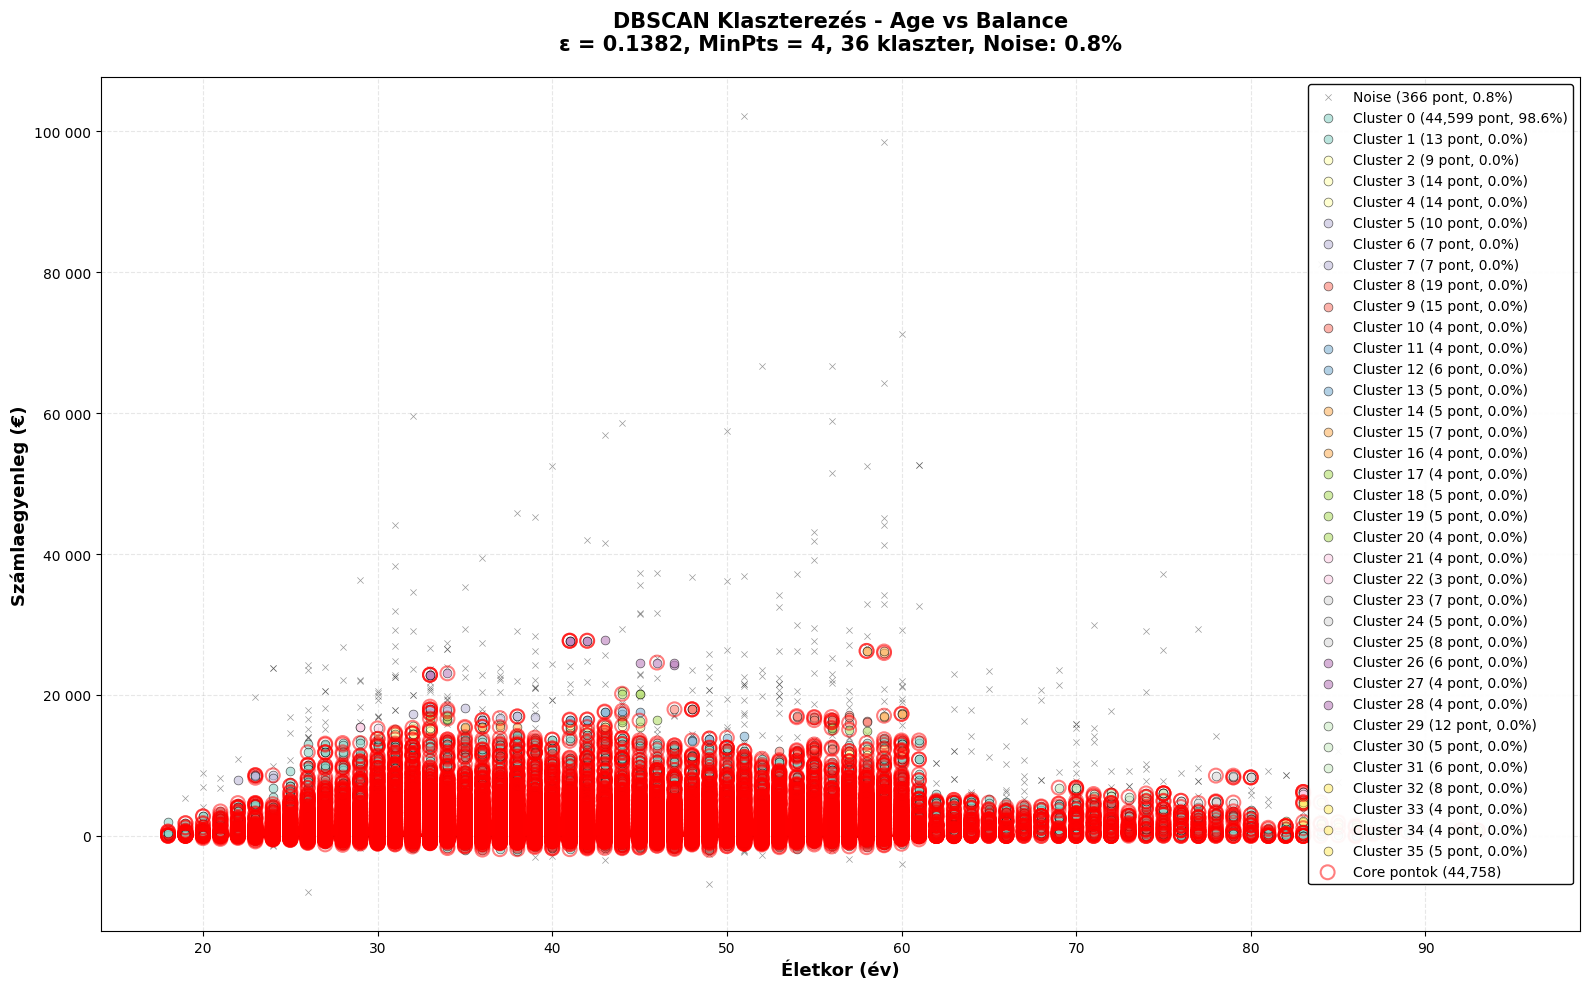

✓ Scatter plot mentve: exports_dbscan/dbscan_scatter_plot.png


In [14]:
# Scatter plot - Age vs Balance (DBSCAN klaszterek)
fig, ax = plt.subplots(figsize=(16, 10))

# Színek: noise = fekete, klaszterek = színesek
unique_labels = sorted(set(optimal_labels))
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))

for idx, cluster_id in enumerate(unique_labels):
    cluster_data = df[df['cluster'] == cluster_id]
    
    if cluster_id == -1:
        # Noise pontok - fekete
        ax.scatter(cluster_data['age'], cluster_data['balance'], 
                  label=f'Noise ({len(cluster_data):,} pont, {len(cluster_data)/len(df)*100:.1f}%)', 
                  alpha=0.4, s=20, c='black', marker='x', linewidths=0.5)
    else:
        # Klaszter pontok
        ax.scatter(cluster_data['age'], cluster_data['balance'], 
                  label=f'Cluster {cluster_id} ({len(cluster_data):,} pont, {len(cluster_data)/len(df)*100:.1f}%)', 
                  alpha=0.6, s=40, c=[colors[idx]], edgecolors='black', linewidths=0.5)

# Core pontok kiemelése (nagyobb marker)
core_mask = np.zeros(len(df), dtype=bool)
core_mask[optimal_dbscan.core_sample_indices_] = True
core_points = df[core_mask]

ax.scatter(core_points['age'], core_points['balance'], 
          s=100, facecolors='none', edgecolors='red', linewidths=1.5, 
          label=f'Core pontok ({len(core_points):,})', alpha=0.5, zorder=5)

ax.set_xlabel('Életkor (év)', fontsize=13, fontweight='bold')
ax.set_ylabel('Számlaegyenleg (€)', fontsize=13, fontweight='bold')
ax.set_title(f'DBSCAN Klaszterezés - Age vs Balance\n' + 
            f'ε = {optimal_eps:.4f}, MinPts = {min_pts}, ' +
            f'{optimal_result["n_clusters"]} klaszter, ' +
            f'Noise: {optimal_result["noise_ratio"]:.1f}%', 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3, linestyle='--')

# Y tengely formázása
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', ' ')))

plt.tight_layout()
plt.savefig('exports_dbscan/dbscan_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scatter plot mentve: exports_dbscan/dbscan_scatter_plot.png")

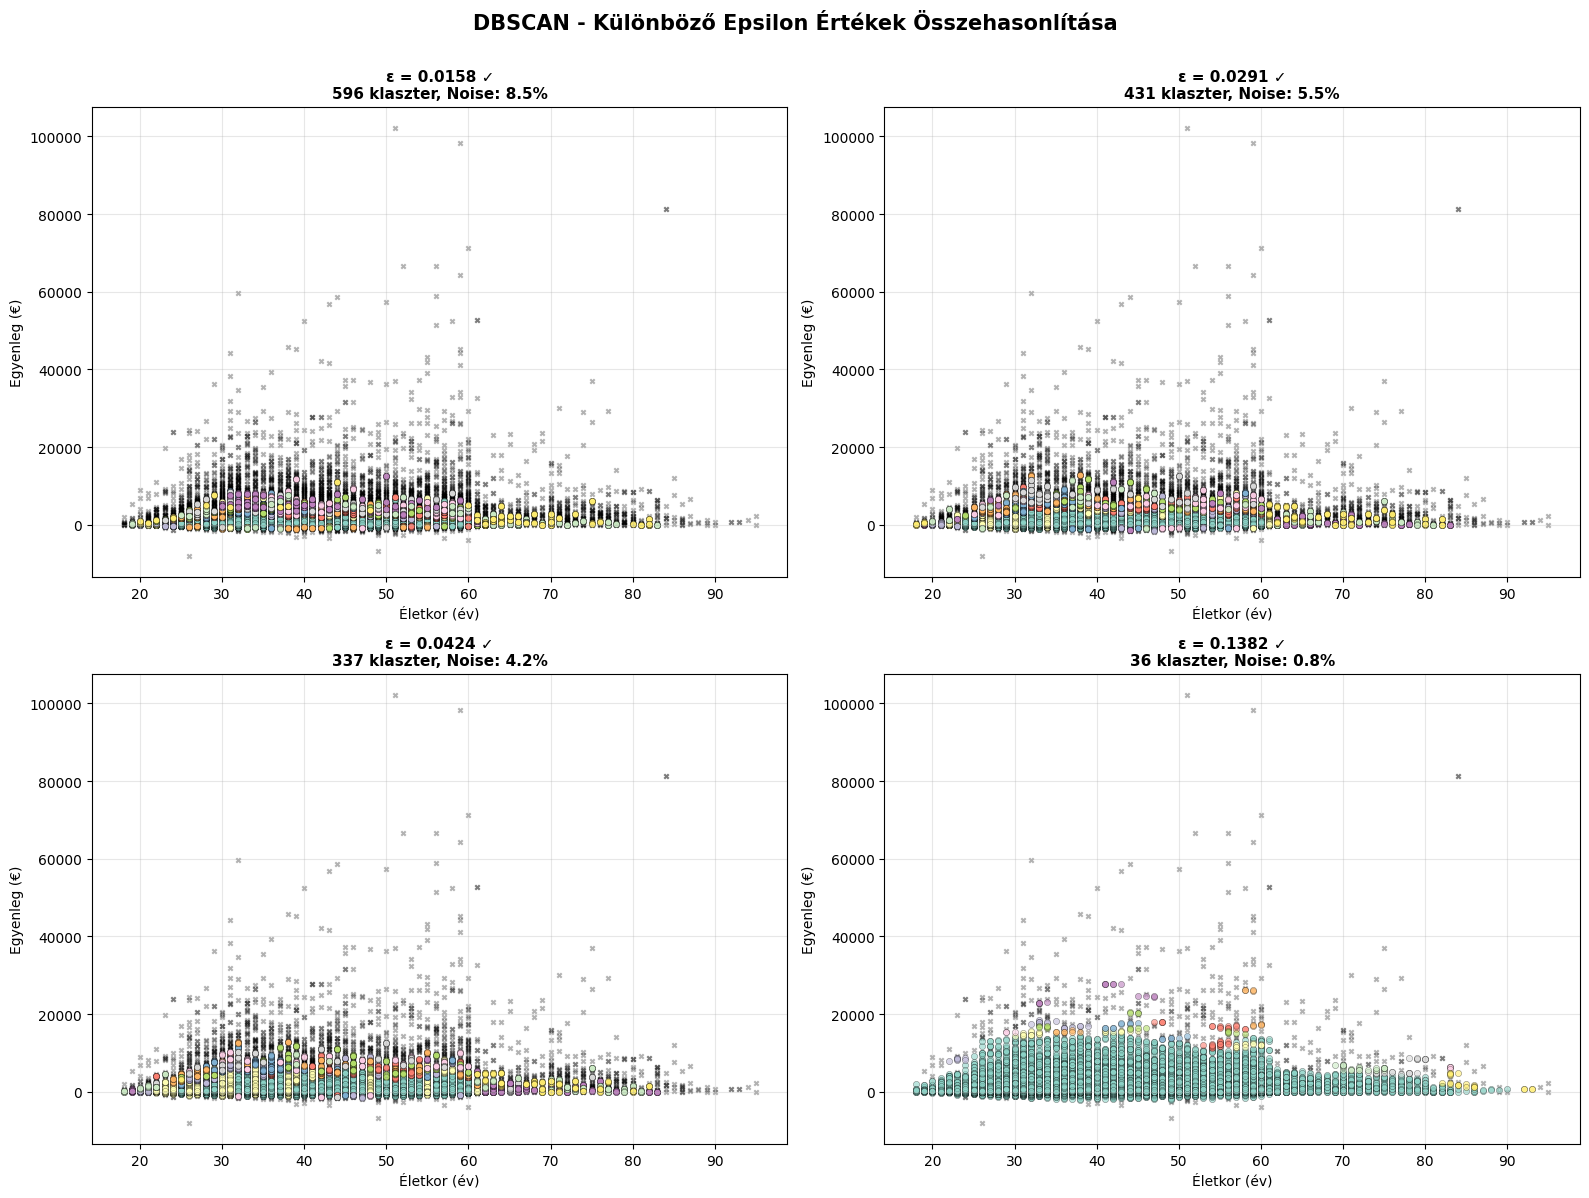

✓ Epsilon összehasonlító plot mentve: exports_dbscan/dbscan_epsilon_comparison.png


In [15]:
# Epsilon összehasonlító vizualizáció
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, result in enumerate(results[:4]):  # Első 4 epsilon érték
    ax = axes[idx]
    
    labels = result['labels']
    eps = result['epsilon']
    
    # Színezés
    unique_labels = sorted(set(labels))
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
    
    for label_idx, cluster_id in enumerate(unique_labels):
        cluster_mask = labels == cluster_id
        
        if cluster_id == -1:
            ax.scatter(df.loc[cluster_mask, 'age'], df.loc[cluster_mask, 'balance'], 
                      alpha=0.3, s=10, c='black', marker='x')
        else:
            ax.scatter(df.loc[cluster_mask, 'age'], df.loc[cluster_mask, 'balance'], 
                      alpha=0.6, s=20, c=[colors[label_idx]], edgecolors='black', linewidths=0.3)
    
    status = "✓" if result['noise_ratio'] <= 15 else "⚠"
    ax.set_title(f'ε = {eps:.4f} {status}\n' + 
                f'{result["n_clusters"]} klaszter, Noise: {result["noise_ratio"]:.1f}%', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Életkor (év)', fontsize=10)
    ax.set_ylabel('Egyenleg (€)', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('DBSCAN - Különböző Epsilon Értékek Összehasonlítása', 
            fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('exports_dbscan/dbscan_epsilon_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Epsilon összehasonlító plot mentve: exports_dbscan/dbscan_epsilon_comparison.png")

## 11. Összefoglaló és Következtetések

In [16]:
print("\n" + "="*100)
print("DBSCAN KLASZTEREZÉS - VÉGSŐ ÖSSZEFOGLALÓ")
print("="*100)

print(f"\n1. MÓDSZERTAN:")
print(f"   - Algoritmus: DBSCAN (Density-Based Spatial Clustering)")
print(f"   - Epsilon optimalizálás: k-distance graph módszer")
print(f"   - MinPts: {min_pts} (2 × dimenziószám)")
print(f"   - Használt változók: age, balance")
print(f"   - Normalizálás: StandardScaler")

print(f"\n2. OPTIMÁLIS PARAMÉTEREK:")
print(f"   - Epsilon (ε): {optimal_eps:.4f}")
print(f"   - MinPts: {min_pts}")
print(f"   - Forrás: k-distance graph, 95. percentilis")

print(f"\n3. DBSCAN EREDMÉNYEK:")
print(f"   - Azonosított klaszterek: {optimal_result['n_clusters']}")
print(f"   - Core pontok: {optimal_result['n_core']:,} ({optimal_result['n_core']/len(df)*100:.1f}%)")
print(f"   - Border pontok: {len(df) - optimal_result['n_core'] - optimal_result['n_noise']:,}")
print(f"   - Noise pontok: {optimal_result['n_noise']:,} ({optimal_result['noise_ratio']:.2f}%)")

if optimal_result['noise_ratio'] <= 15:
    print(f"   ✓ Noise arány megfelelő (<= 15%)")
else:
    print(f"   ⚠ Noise arány túl magas (> 15%)")

if not np.isnan(optimal_result['silhouette']):
    print(f"\n4. VALIDÁCIÓS METRIKÁK (noise nélkül):")
    print(f"   - Silhouette Score: {optimal_result['silhouette']:.4f}")
    print(f"   - Davies-Bouldin Index: {optimal_result['davies_bouldin']:.4f}")
    print(f"   - Calinski-Harabasz Index: {optimal_result['calinski_harabasz']:.2f}")

print(f"\n5. KLASZTEREK RÉSZLETEI:")
for _, row in profile_df.iterrows():
    label = row['Klaszter']
    count = int(row['Elemszám (db)'])
    pct = row['Elemszám (%)']
    avg_age = row['Átlag age']
    avg_balance = row['Átlag balance']
    
    if label == 'Noise':
        print(f"   {label}: {count:>6,} pont ({pct:>5.1f}%) - Outliers")
    else:
        print(f"   {label}: {count:>6,} pont ({pct:>5.1f}%) - "
              f"Átlag kor: {avg_age:.0f} év, Átlag egyenleg: {avg_balance:,.0f} €")

print(f"\n6. EXPORTÁLT FÁJLOK:")
print(f"   CSV fájlok:")
print(f"   - exports_dbscan/dbscan_parameters.csv - Epsilon tesztelési eredmények")
print(f"   - exports_dbscan/dbscan_metrics.csv - Validációs metrikák")
print(f"   - exports_dbscan/dbscan_cluster_profiles.csv - Klaszter profilok")
print(f"   \n   PNG ábrák:")
print(f"   - exports_dbscan/kdistance_graph.png - k-distance graph")
print(f"   - exports_dbscan/dbscan_scatter_plot.png - Scatter plot")
print(f"   - exports_dbscan/dbscan_epsilon_comparison.png - Epsilon összehasonlítás")

print(f"\n7. KÖVETKEZTETÉSEK:")
if optimal_result['noise_ratio'] <= 15 and optimal_result['n_clusters'] >= 2:
    print(f"   ✓ A DBSCAN sikeresen azonosított {optimal_result['n_clusters']} sűrűség-alapú")
    print(f"     klasztert az adathalmazban.")
    print(f"   ✓ A noise arány elfogadható ({optimal_result['noise_ratio']:.1f}%).")
    print(f"   ✓ A {optimal_result['n_noise']:,} noise pont valódi outlier lehet.")
else:
    print(f"   ⚠ A DBSCAN nem optimális erre az adathalmazra:")
    if optimal_result['noise_ratio'] > 15:
        print(f"     - Túl magas noise arány ({optimal_result['noise_ratio']:.1f}% > 15%)")
    if optimal_result['n_clusters'] < 2:
        print(f"     - Túl kevés klaszter ({optimal_result['n_clusters']})")
    print(f"   ⚠ Az adathalmaz nem tartalmaz jól definiált sűrűség-alapú")
    print(f"     klasztereket. Érdemes K-means vagy hierarchikus klaszterezést")
    print(f"     használni helyette.")

print("\n" + "="*100)
print("✓ DBSCAN KLASZTEREZÉS SIKERESEN BEFEJEZVE!")
print("="*100)


DBSCAN KLASZTEREZÉS - VÉGSŐ ÖSSZEFOGLALÓ

1. MÓDSZERTAN:
   - Algoritmus: DBSCAN (Density-Based Spatial Clustering)
   - Epsilon optimalizálás: k-distance graph módszer
   - MinPts: 4 (2 × dimenziószám)
   - Használt változók: age, balance
   - Normalizálás: StandardScaler

2. OPTIMÁLIS PARAMÉTEREK:
   - Epsilon (ε): 0.1382
   - MinPts: 4
   - Forrás: k-distance graph, 95. percentilis

3. DBSCAN EREDMÉNYEK:
   - Azonosított klaszterek: 36
   - Core pontok: 44,758 (99.0%)
   - Border pontok: 87
   - Noise pontok: 366 (0.81%)
   ✓ Noise arány megfelelő (<= 15%)

4. VALIDÁCIÓS METRIKÁK (noise nélkül):
   - Silhouette Score: 0.4334
   - Davies-Bouldin Index: 0.4758
   - Calinski-Harabasz Index: 121.70

5. KLASZTEREK RÉSZLETEI:
   Noise:    366 pont (  0.8%) - Outliers
   Cluster_0: 44,599 pont ( 98.6%) - Átlag kor: 41 év, Átlag egyenleg: 1,142 €
   Cluster_1:     13 pont (  0.0%) - Átlag kor: 59 év, Átlag egyenleg: 13,285 €
   Cluster_2:      9 pont (  0.0%) - Átlag kor: 43 év, Átlag egye